# Visualisasi Tujuan 3 — Implementasi dan Evaluasi Sistem QA Berbasis RAG (Bab 4.3)

Notebook ini hanya membaca artefak aktual di `Hasil/tujuan3`. Tidak ada skor, waktu,
jumlah pengujian, konfigurasi, atau hasil penelitian yang digunakan sebagai fallback.
Kelompok visualisasi dilewati dengan pesan eksplisit bila artefak sumbernya belum tersedia.

Cakupan:

- arsitektur pipeline aktual dari manifest dan hasil preflight;
- evaluasi ablasi RAGAS;
- evaluasi skenario, gaya bahasa, dan kesalahan ketik;
- retrieval, performa end-to-end, throughput, dan penggunaan sumber daya;
- pengujian streaming dan black-box.


## Setup dan pemuatan artefak hasil


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan3

/content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan3


In [10]:
%matplotlib inline
import json
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.3, "axes.axisbelow": True, "figure.dpi": 150,
})

C_BLUE, C_ORANGE, C_GREEN = "#2c6fbb", "#e08a1e", "#3a7d44"
C_RED, C_PURPLE, C_GRAY = "#c0392b", "#8e5ea2", "#7f8c8d"
MODEL_LABELS = {
    "llama3.2-finetuned": "Llama-3.2 (fine-tuned)",
    "gemma2-finetuned": "Gemma-2 (fine-tuned)",
    "deepseek-flash": "DeepSeek-Flash",
    "llama3.2": "Llama-3.2",
    "gemma2": "Gemma-2",
    "deepseek": "DeepSeek-Flash",
}

def temukan_root(mulai=Path.cwd()):
    mulai = Path(mulai).resolve()
    for kandidat in (mulai, *mulai.parents):
        if (kandidat / "Hasil" / "tujuan3").is_dir():
            return kandidat
    raise FileNotFoundError("Root proyek dengan Hasil/tujuan3 tidak ditemukan.")

PROJECT_ROOT = temukan_root()
DATA_TUJUAN3 = PROJECT_ROOT / "Hasil" / "tujuan3"

def hasil_t3(nama, wajib=False):
    cocok = sorted(DATA_TUJUAN3.rglob(nama))
    if len(cocok) > 1:
        raise RuntimeError(f"Artefak ambigu, ditemukan lebih dari satu {nama}: {cocok}")
    if cocok:
        return cocok[0]
    tujuan = DATA_TUJUAN3 / nama
    if wajib:
        raise FileNotFoundError(f"Artefak wajib belum ada di Hasil/tujuan3: {nama}")
    return tujuan

def baca_json(nama, wajib=False):
    p = hasil_t3(nama, wajib=wajib)
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None

def baca_csv(nama, wajib=False):
    p = hasil_t3(nama, wajib=wajib)
    return pd.read_csv(p) if p.exists() else None

def lewati(pesan):
    print(f"[DILEWATI] {pesan}")

def label_model(kunci):
    return MODEL_LABELS.get(str(kunci), str(kunci).replace("_", " "))

def label_skenario(kunci):
    return re.sub(r"^\d+_", "", str(kunci)).replace("_", " ").title()

manifest = baca_json("scenario_generation_manifest.json", wajib=True)
preflight = baca_json("preflight.json", wajib=True)
perf_environment = baca_json("system_performance_environment.json", wajib=True)
coverage_system = baca_json("coverage.json", wajib=True)
functional_results = baca_json("functional_results.json", wajib=True)
stream_result = baca_json("stream_stage_test.json", wajib=True)

scenario_results = baca_csv("scenario_results.csv", wajib=True)
scenario_by_model = baca_csv("scenario_ragas_summary_by_model.csv", wajib=True)
scenario_by_scenario = baca_csv("scenario_ragas_summary_by_scenario.csv", wajib=True)
scenario_coverage = baca_csv("scenario_ragas_coverage.csv", wajib=True)
style_comparison = baca_csv("scenario_ragas_style_comparison.csv", wajib=True)
typo_comparison = baca_csv("scenario_ragas_typo_comparison.csv", wajib=True)
performance = baca_csv("system_performance_all.csv", wajib=True)

ragas_summary = baca_csv("ragas_summary.csv")
ragas_deltas = baca_csv("ragas_paired_differences.csv")

print(f"Sumber data             : {DATA_TUJUAN3}")
print(f"Hasil skenario          : {len(scenario_results):,} baris")
print(f"Pengukuran performa     : {len(performance):,} baris")
print(f"Kasus uji fungsional    : {len(functional_results):,}")
print(f"Ablasi RAGAS            : {'tersedia' if ragas_summary is not None else 'belum tersedia'}")
print(f"Delta berpasangan RAGAS : {'tersedia' if ragas_deltas is not None else 'belum tersedia'}")


Sumber data             : /content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan3
Hasil skenario          : 60 baris
Pengukuran performa     : 112 baris
Kasus uji fungsional    : 7
Ablasi RAGAS            : tersedia
Delta berpasangan RAGAS : tersedia


## 1. Arsitektur dan alur pipeline aktual

Tahapan pipeline, model, serta konfigurasi diambil dari `scenario_generation_manifest.json`,
`preflight.json`, dan `system_performance_environment.json`.


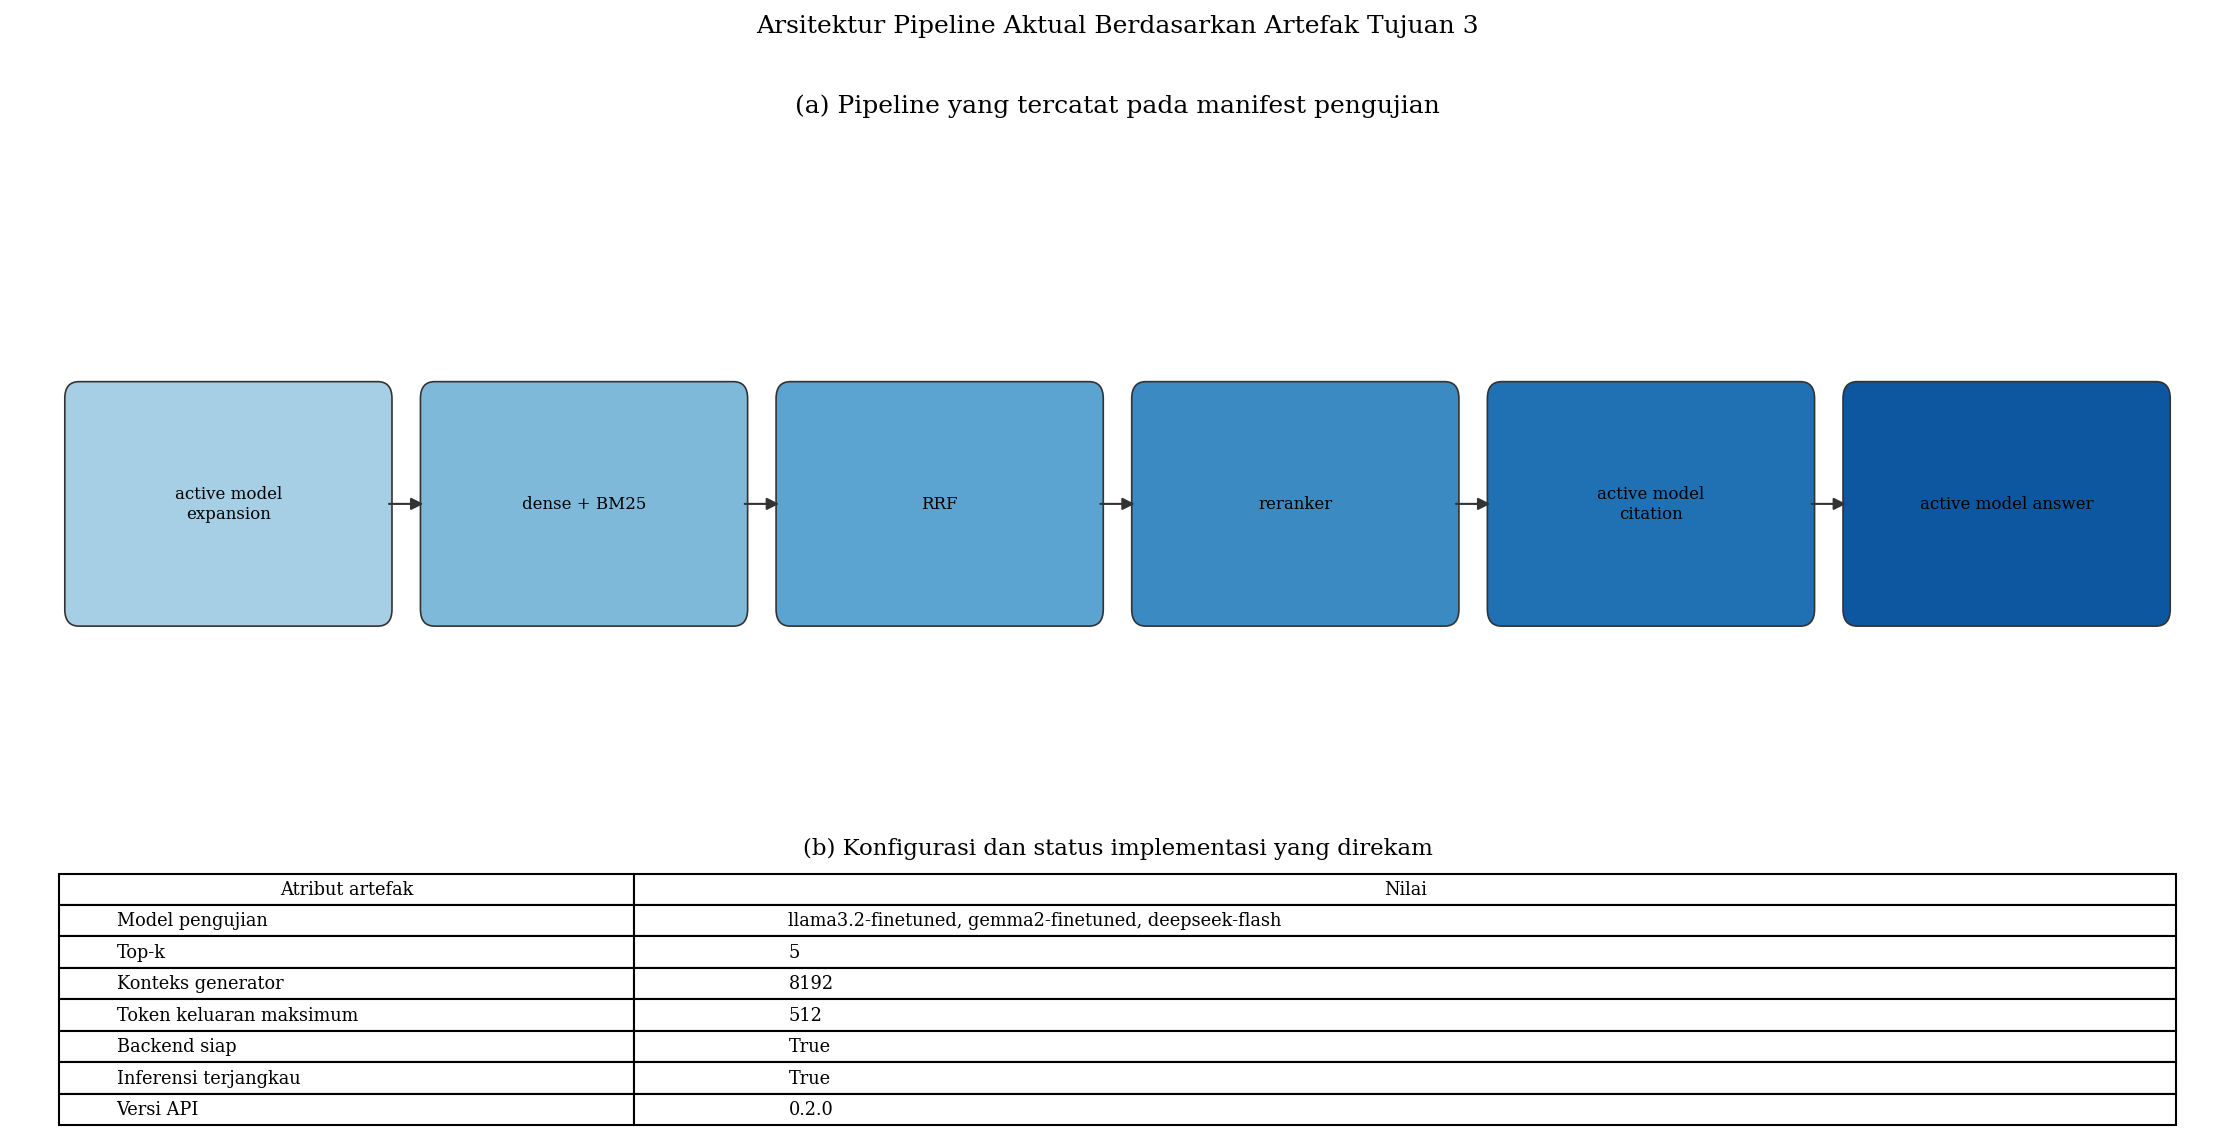

In [11]:
def fig1_pipeline_aktual():
    pipeline_text = manifest["pipeline"]
    tahap = [x.strip() for x in pipeline_text.split("->") if x.strip()]
    n = len(tahap)
    fig, axes = plt.subplots(2, 1, figsize=(15, 7.5), gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.set_xlim(-.6, n - .4); ax.set_ylim(-.7, .9); ax.axis("off")
    warna = plt.cm.Blues(np.linspace(.35, .85, max(n, 2)))
    kotak = []
    for i, nama in enumerate(tahap):
        teks = textwrap.fill(nama.replace("+", " + "), width=20)
        b = FancyBboxPatch((i - .42, -.25), .84, .5, boxstyle="round,pad=.04",
                           facecolor=warna[i], edgecolor="#333333", linewidth=.8)
        ax.add_patch(b); kotak.append(b)
        ax.text(i, 0, teks, ha="center", va="center", fontsize=8)
        if i:
            ax.add_patch(FancyArrowPatch((i - 1 + .44, 0), (i - .44, 0),
                                         arrowstyle="-|>", mutation_scale=12,
                                         linewidth=1, color="#333333"))
    ax.set_title("(a) Pipeline yang tercatat pada manifest pengujian")

    ax = axes[1]; ax.axis("off"); ax.grid(False)
    health = preflight.get("health", {})
    isi = [
        ["Model pengujian", ", ".join(map(str, manifest.get("model_keys", [])))],
        ["Top-k", manifest.get("top_k")],
        ["Konteks generator", manifest.get("num_ctx")],
        ["Token keluaran maksimum", manifest.get("max_new_tokens")],
        ["Backend siap", health.get("ready")],
        ["Inferensi terjangkau", health.get("inference_reachable")],
        ["Versi API", preflight.get("api_version")],
    ]
    tabel = ax.table(cellText=isi, colLabels=["Atribut artefak", "Nilai"],
                     loc="center", cellLoc="left", colWidths=[.25, .67], bbox=[.02, .01, .96, .82])
    tabel.auto_set_font_size(False); tabel.set_fontsize(8.5); tabel.scale(1, 1.45)
    ax.text(.5, .95, "(b) Konfigurasi dan status implementasi yang direkam",
        transform=ax.transAxes, ha="center", va="top", fontsize=11)
    fig.suptitle("Arsitektur Pipeline Aktual Berdasarkan Artefak Tujuan 3", y=1.01)
    plt.tight_layout(); plt.savefig("fig01_pipeline_aktual.png", bbox_inches="tight"); plt.show()

fig1_pipeline_aktual()


### Alur event streaming satu permintaan

Urutan dan waktunya berasal dari `stream_stage_test.json`, bukan dari diagram statis.


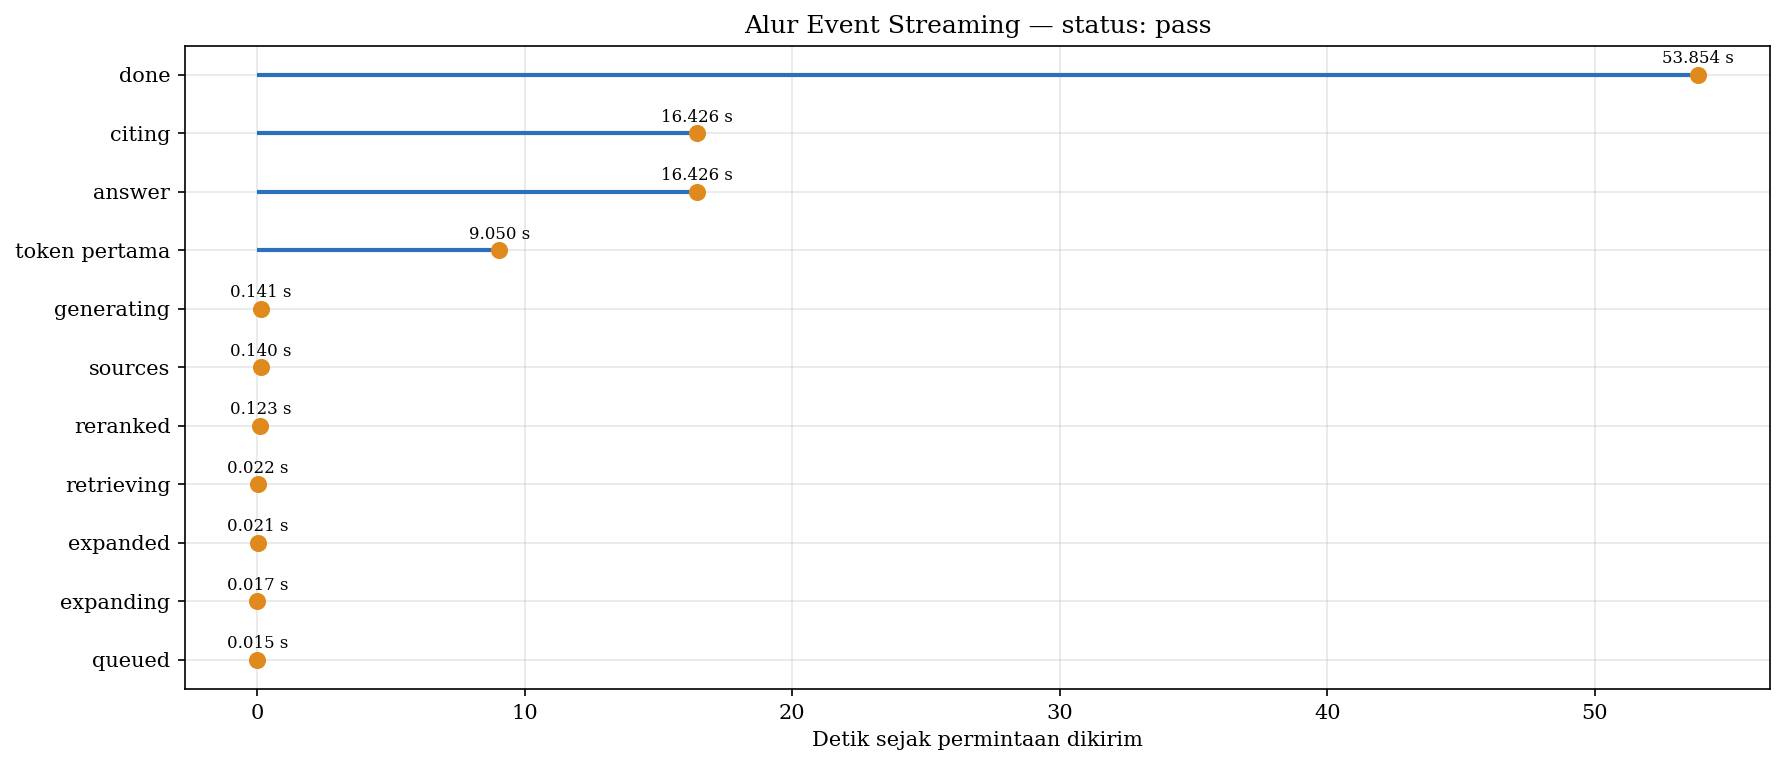

In [12]:
def fig2_timeline_streaming():
    events = pd.DataFrame(stream_result["events"])
    pertama = (events[~events["event"].isin(["heartbeat", "token"])]
               .groupby("event", as_index=False)["elapsed_s"].min()
               .sort_values("elapsed_s"))
    token = events[events["event"] == "token"]["elapsed_s"]
    if len(token):
        pertama = pd.concat([pertama, pd.DataFrame({"event": ["token pertama"],
                                                    "elapsed_s": [token.min()]})], ignore_index=True)
        pertama = pertama.sort_values("elapsed_s")

    fig, ax = plt.subplots(figsize=(12, 5.2))
    y = np.arange(len(pertama))
    ax.hlines(y, 0, pertama["elapsed_s"], color=C_BLUE, lw=2)
    ax.scatter(pertama["elapsed_s"], y, color=C_ORANGE, s=52, zorder=3)
    for yi, v in zip(y, pertama["elapsed_s"]):
        ax.text(v, yi + .2, f"{v:.3f} s", ha="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(pertama["event"].str.replace("_", " "))
    ax.set_xlabel("Detik sejak permintaan dikirim")
    ax.set_title(f"Alur Event Streaming — status: {stream_result['status']}")
    plt.tight_layout(); plt.savefig("fig02_timeline_streaming.png", bbox_inches="tight"); plt.show()

fig2_timeline_streaming()


## 2. Evaluasi ablasi RAGAS

Bagian ini otomatis aktif setelah `ragas_summary.csv` dan
`ragas_paired_differences.csv` ditempatkan di `Hasil/tujuan3`.


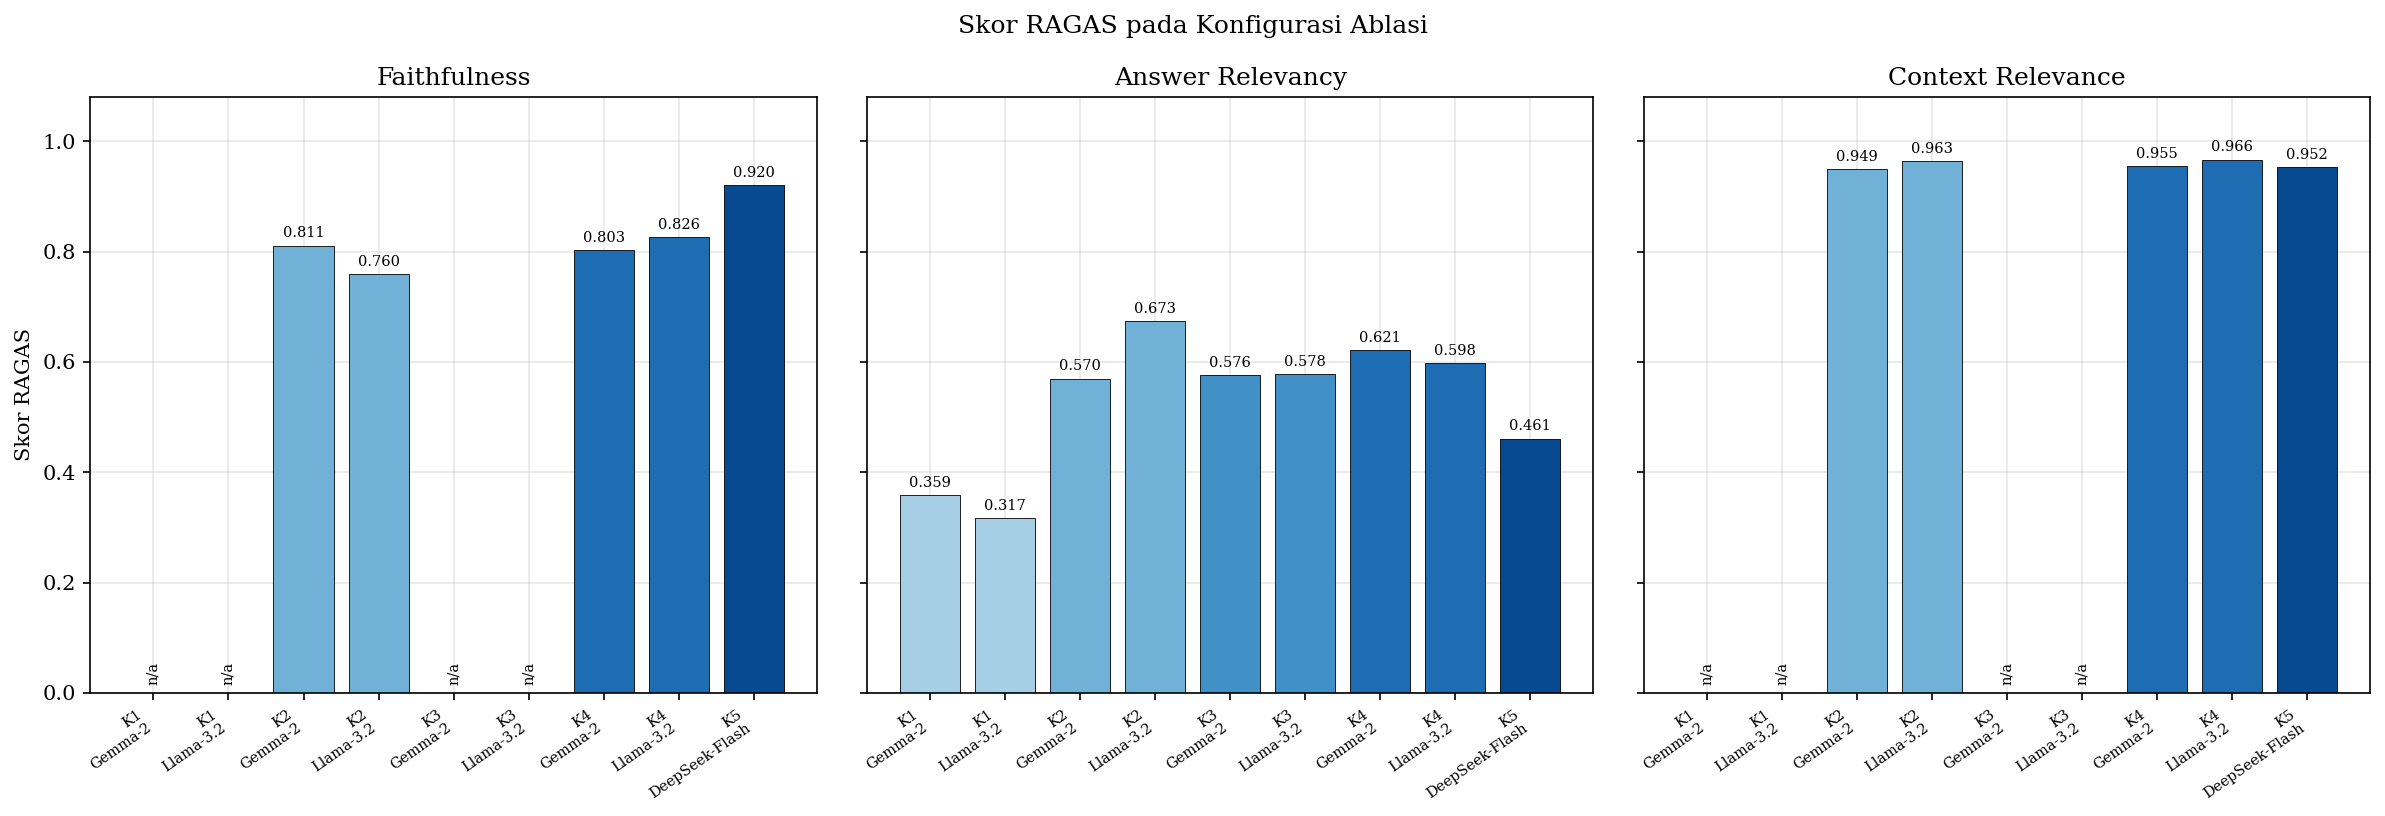

In [13]:
def fig3_ragas_ablasi():
    if ragas_summary is None:
        lewati("fig03: ragas_summary.csv belum tersedia."); return
    d = ragas_summary.copy()
    if "protocol" in d and (d["protocol"] == "end_to_end").any():
        d = d[d["protocol"] == "end_to_end"].copy()
    d["condition_order"] = d["condition"].astype(str).str.extract(r"(\d+)")[0].astype(float)
    d = d.sort_values(["condition_order", "architecture"])
    d["label"] = d["condition"].astype(str) + "\n" + d["architecture"].map(label_model)
    metrik = [("faithfulness", "Faithfulness"),
              ("answer_relevancy", "Answer Relevancy"),
              ("context_relevance", "Context Relevance")]
    fig, axes = plt.subplots(1, len(metrik), figsize=(16, 5.5), sharey=True)
    kondisi = list(dict.fromkeys(d["condition"].astype(str)))
    palet = dict(zip(kondisi, plt.cm.Blues(np.linspace(.35, .9, max(len(kondisi), 2)))))
    warna = [palet[str(k)] for k in d["condition"]]
    for ax, (kolom, judul) in zip(axes, metrik):
        nilai = d[kolom].to_numpy(float)
        ax.bar(np.arange(len(d)), np.nan_to_num(nilai), color=warna, edgecolor="black", linewidth=.4)
        for x, v in enumerate(nilai):
            ax.text(x, .02 if np.isnan(v) else v + .015,
                    "n/a" if np.isnan(v) else f"{v:.3f}", ha="center", fontsize=7, rotation=90 if np.isnan(v) else 0)
        ax.set_xticks(np.arange(len(d))); ax.set_xticklabels(d["label"], rotation=35, ha="right", fontsize=7)
        ax.set_ylim(0, 1.08); ax.set_title(judul)
    axes[0].set_ylabel("Skor RAGAS")
    fig.suptitle("Skor RAGAS pada Konfigurasi Ablasi")
    plt.tight_layout(); plt.savefig("fig03_ragas_ablasi.png", bbox_inches="tight"); plt.show()

fig3_ragas_ablasi()


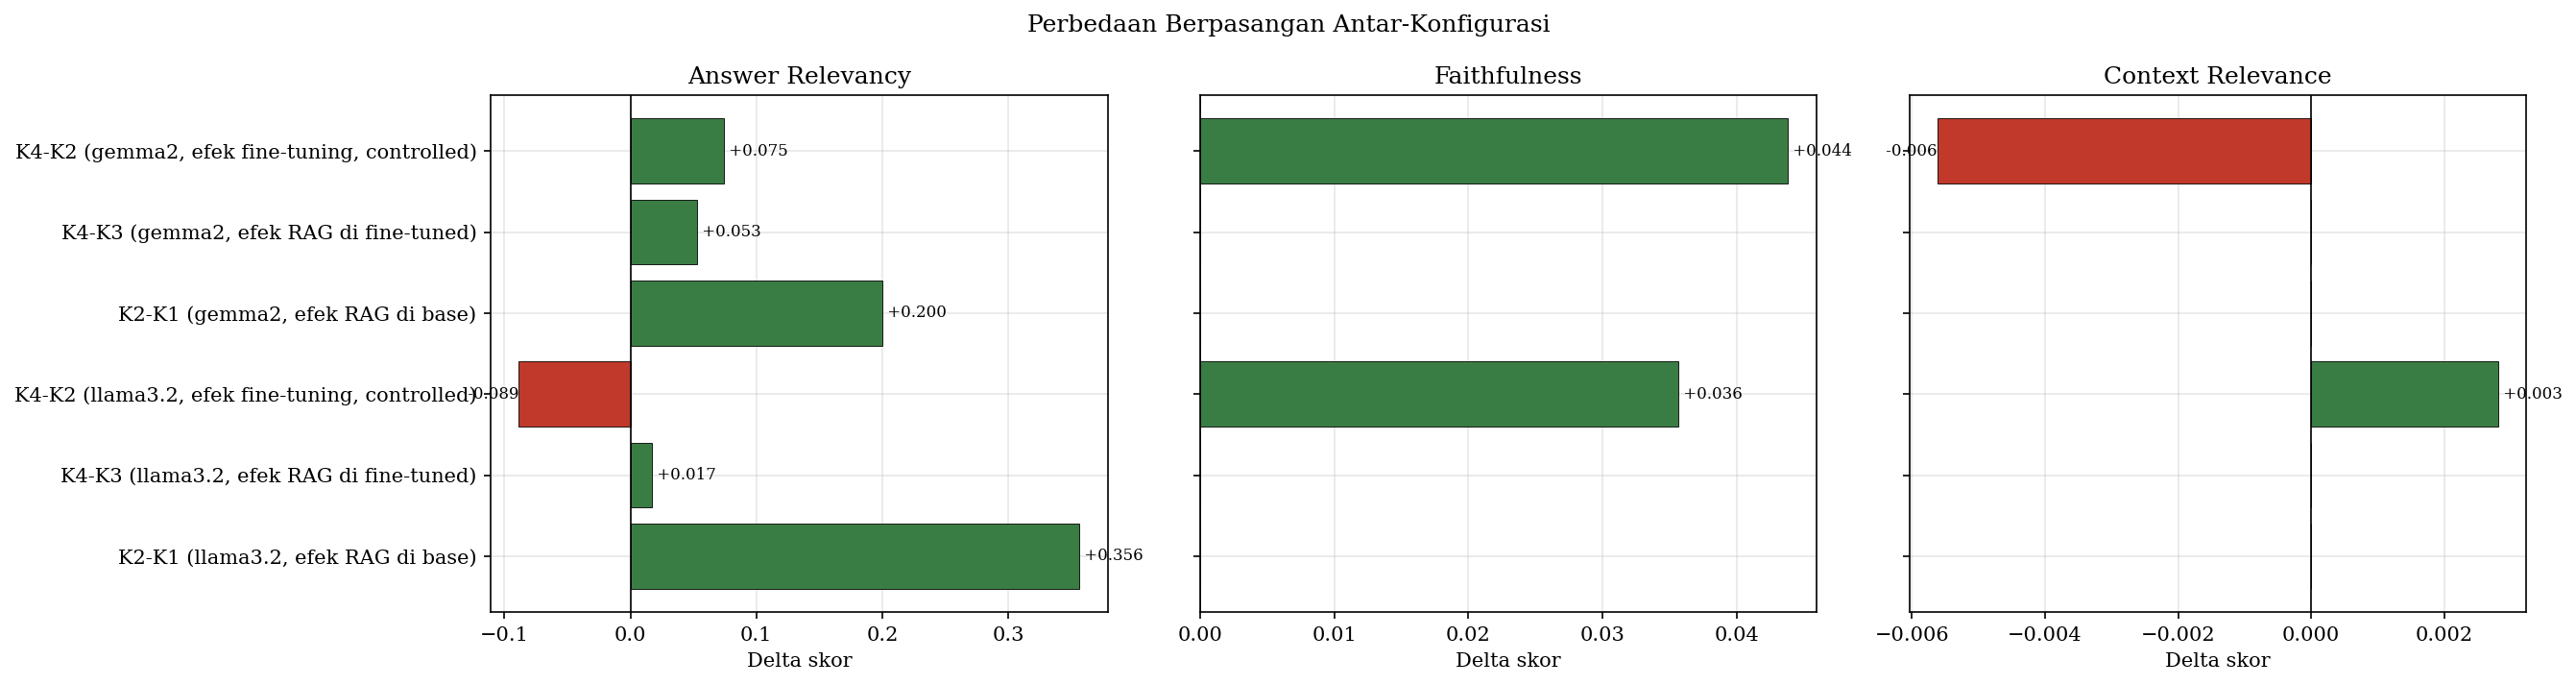

In [14]:
def fig4_delta_ragas():
    if ragas_deltas is None:
        lewati("fig04: ragas_paired_differences.csv belum tersedia."); return
    kolom = [c for c in ["answer_relevancy", "faithfulness", "context_relevance"]
             if c in ragas_deltas and ragas_deltas[c].notna().any()]
    if not kolom:
        lewati("fig04: tidak ada kolom delta RAGAS yang terisi."); return
    d = ragas_deltas.set_index("comparison")[kolom]
    fig, axes = plt.subplots(1, len(kolom), figsize=(6 * len(kolom), max(4.8, .45 * len(d) + 2)), squeeze=False)
    for ax, c in zip(axes[0], kolom):
        nilai = d[c]
        y = np.arange(len(d))
        warna = [C_GREEN if v >= 0 else C_RED for v in nilai.fillna(0)]
        ax.barh(y, nilai.fillna(0), color=warna, edgecolor="black", linewidth=.4)
        ax.axvline(0, color="black", lw=.8)
        for yi, v in zip(y, nilai):
            if pd.notna(v): ax.text(v, yi, f" {v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
        ax.set_yticks(y); ax.set_yticklabels(d.index if ax is axes[0, 0] else [])
        ax.set_xlabel("Delta skor"); ax.set_title(c.replace("_", " ").title())
    fig.suptitle("Perbedaan Berpasangan Antar-Konfigurasi")
    plt.tight_layout(); plt.savefig("fig04_delta_ragas.png", bbox_inches="tight"); plt.show()

fig4_delta_ragas()


## 3. Evaluasi skenario dan robustness


/tmp/ipykernel_391/3741536727.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig("fig05_ragas_per_skenario.png", bbox_inches="tight"); plt.show()


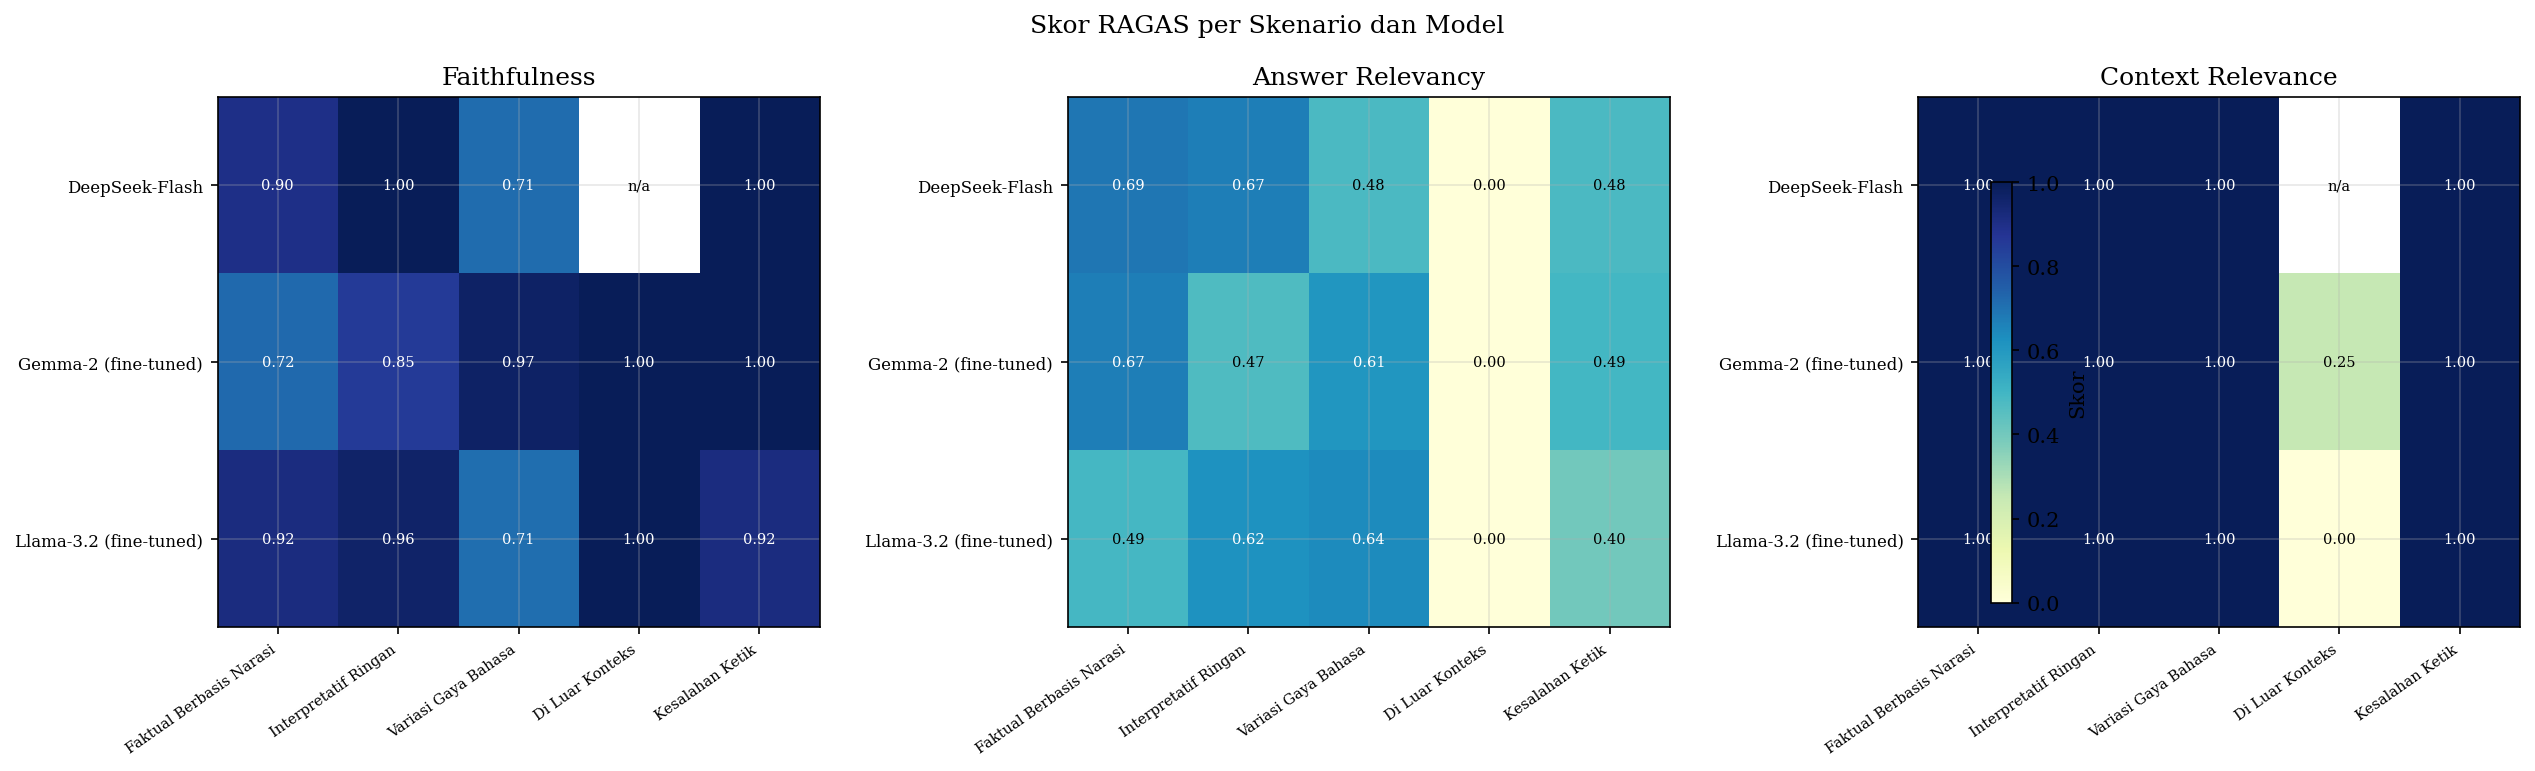

In [15]:
def fig5_ragas_per_skenario():
    d = scenario_by_scenario.copy()
    model_order = sorted(d["model_key"].dropna().unique(), key=str)
    scenario_order = sorted(d["scenario"].dropna().unique(),
                            key=lambda x: int(re.match(r"(\d+)", str(x)).group(1)) if re.match(r"(\d+)", str(x)) else 999)
    metrik = [("faithfulness_mean", "Faithfulness"),
              ("answer_relevancy_mean", "Answer Relevancy"),
              ("context_relevance_mean", "Context Relevance")]
    fig, axes = plt.subplots(1, len(metrik), figsize=(17, 5.2))
    for ax, (kolom, judul) in zip(axes, metrik):
        mat = d.pivot(index="model_key", columns="scenario", values=kolom).reindex(index=model_order, columns=scenario_order)
        im = ax.imshow(mat, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(scenario_order))); ax.set_xticklabels([label_skenario(s) for s in scenario_order], rotation=35, ha="right", fontsize=7)
        ax.set_yticks(range(len(model_order))); ax.set_yticklabels([label_model(m) for m in model_order], fontsize=8)
        for i in range(len(model_order)):
            for j in range(len(scenario_order)):
                v = mat.iloc[i, j]
                ax.text(j, i, "n/a" if pd.isna(v) else f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if pd.notna(v) and v > .58 else "black")
        ax.set_title(judul)
    fig.colorbar(im, ax=axes, shrink=.7, label="Skor")
    fig.suptitle("Skor RAGAS per Skenario dan Model")
    plt.tight_layout(); plt.savefig("fig05_ragas_per_skenario.png", bbox_inches="tight"); plt.show()

fig5_ragas_per_skenario()


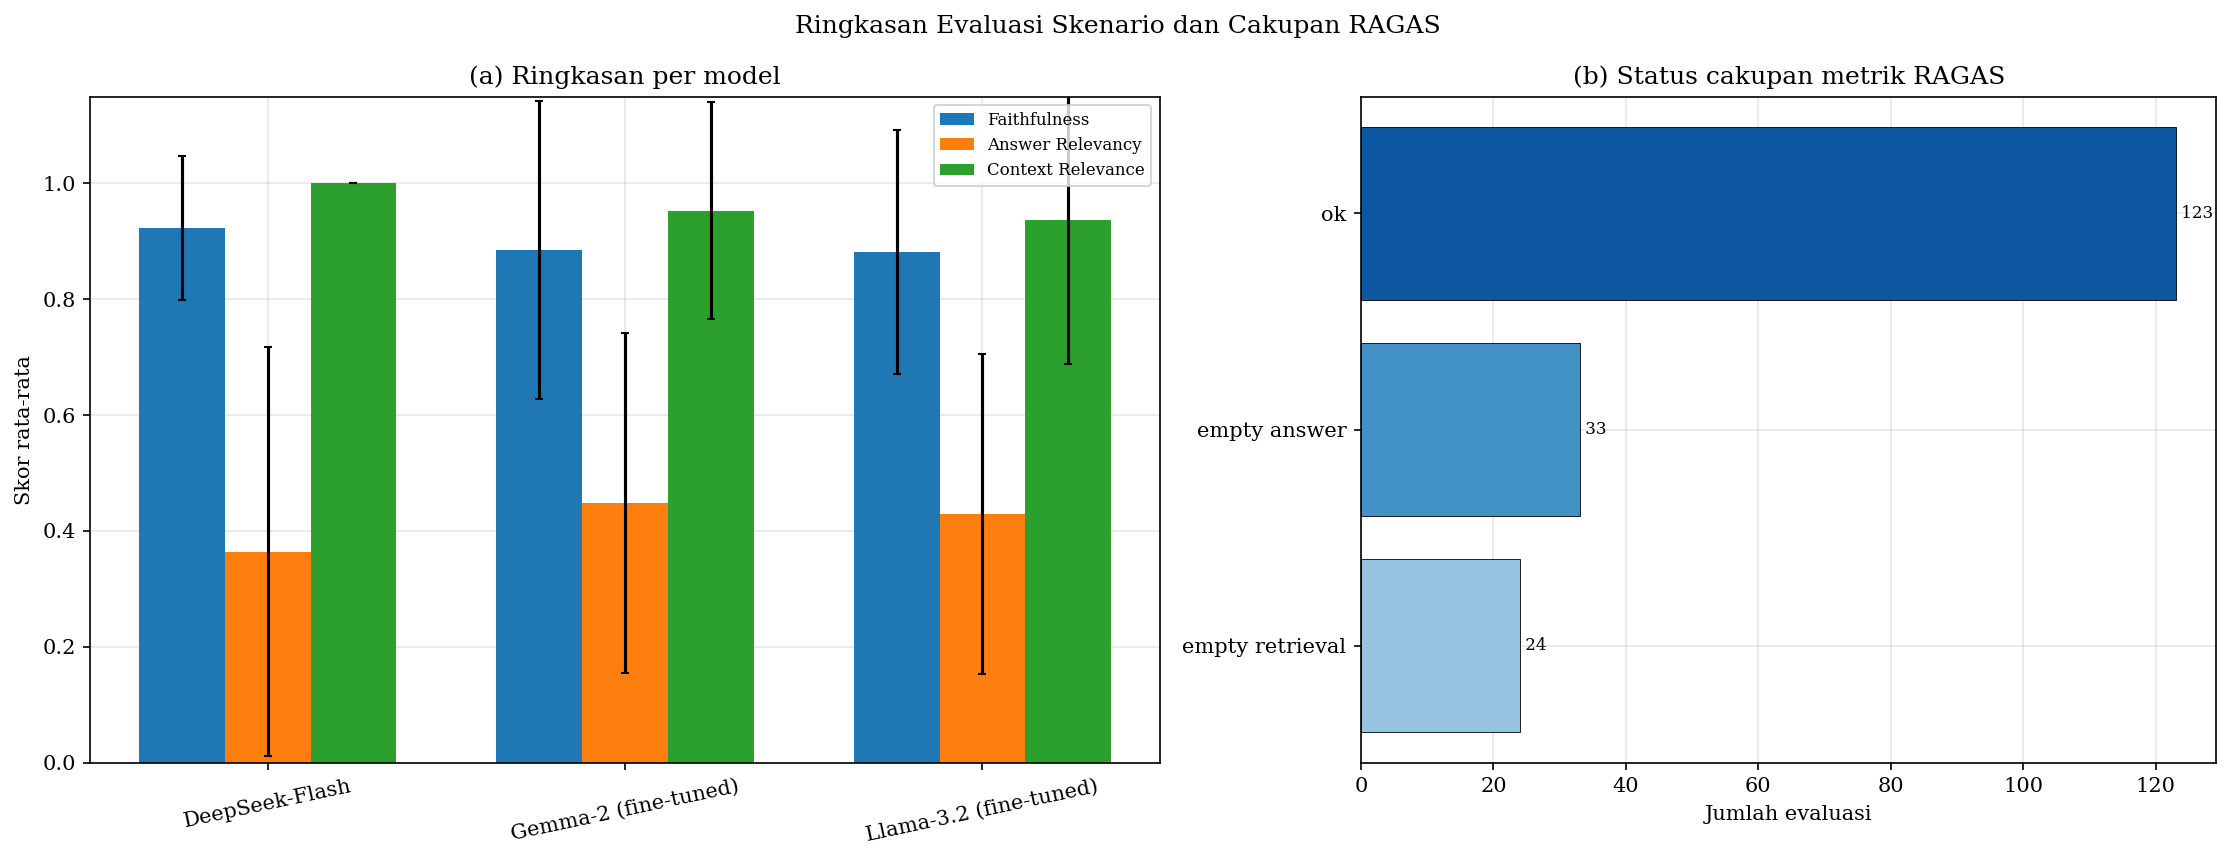

In [16]:
def fig6_ringkasan_model_dan_coverage():
    d = scenario_by_model.copy()
    model_order = list(d["model_key"])
    metrik = [("faithfulness_mean", "Faithfulness"),
              ("answer_relevancy_mean", "Answer Relevancy"),
              ("context_relevance_mean", "Context Relevance")]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.25, 1]})
    ax = axes[0]
    x = np.arange(len(model_order)); w = .24
    for j, (kolom, label) in enumerate(metrik):
        std_col = kolom.replace("_mean", "_std")
        nilai = d[kolom].to_numpy(float)
        galat = d[std_col].fillna(0).to_numpy(float) if std_col in d else None
        ax.bar(x + (j - 1) * w, nilai, w, yerr=galat, capsize=2, label=label)
    ax.set_xticks(x); ax.set_xticklabels([label_model(m) for m in model_order], rotation=12)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Skor rata-rata"); ax.set_title("(a) Ringkasan per model"); ax.legend(fontsize=8)

    ax = axes[1]
    cov = scenario_coverage.groupby("status", as_index=True)["n"].sum().sort_values()
    ax.barh(cov.index.str.replace("_", " "), cov.values, color=plt.cm.Blues(np.linspace(.4, .85, len(cov))), edgecolor="black", linewidth=.4)
    for y, v in enumerate(cov): ax.text(v, y, f" {v:,}", va="center", fontsize=8)
    ax.set_xlabel("Jumlah evaluasi"); ax.set_title("(b) Status cakupan metrik RAGAS")
    fig.suptitle("Ringkasan Evaluasi Skenario dan Cakupan RAGAS")
    plt.tight_layout(); plt.savefig("fig06_ringkasan_model_coverage.png", bbox_inches="tight"); plt.show()

fig6_ringkasan_model_dan_coverage()


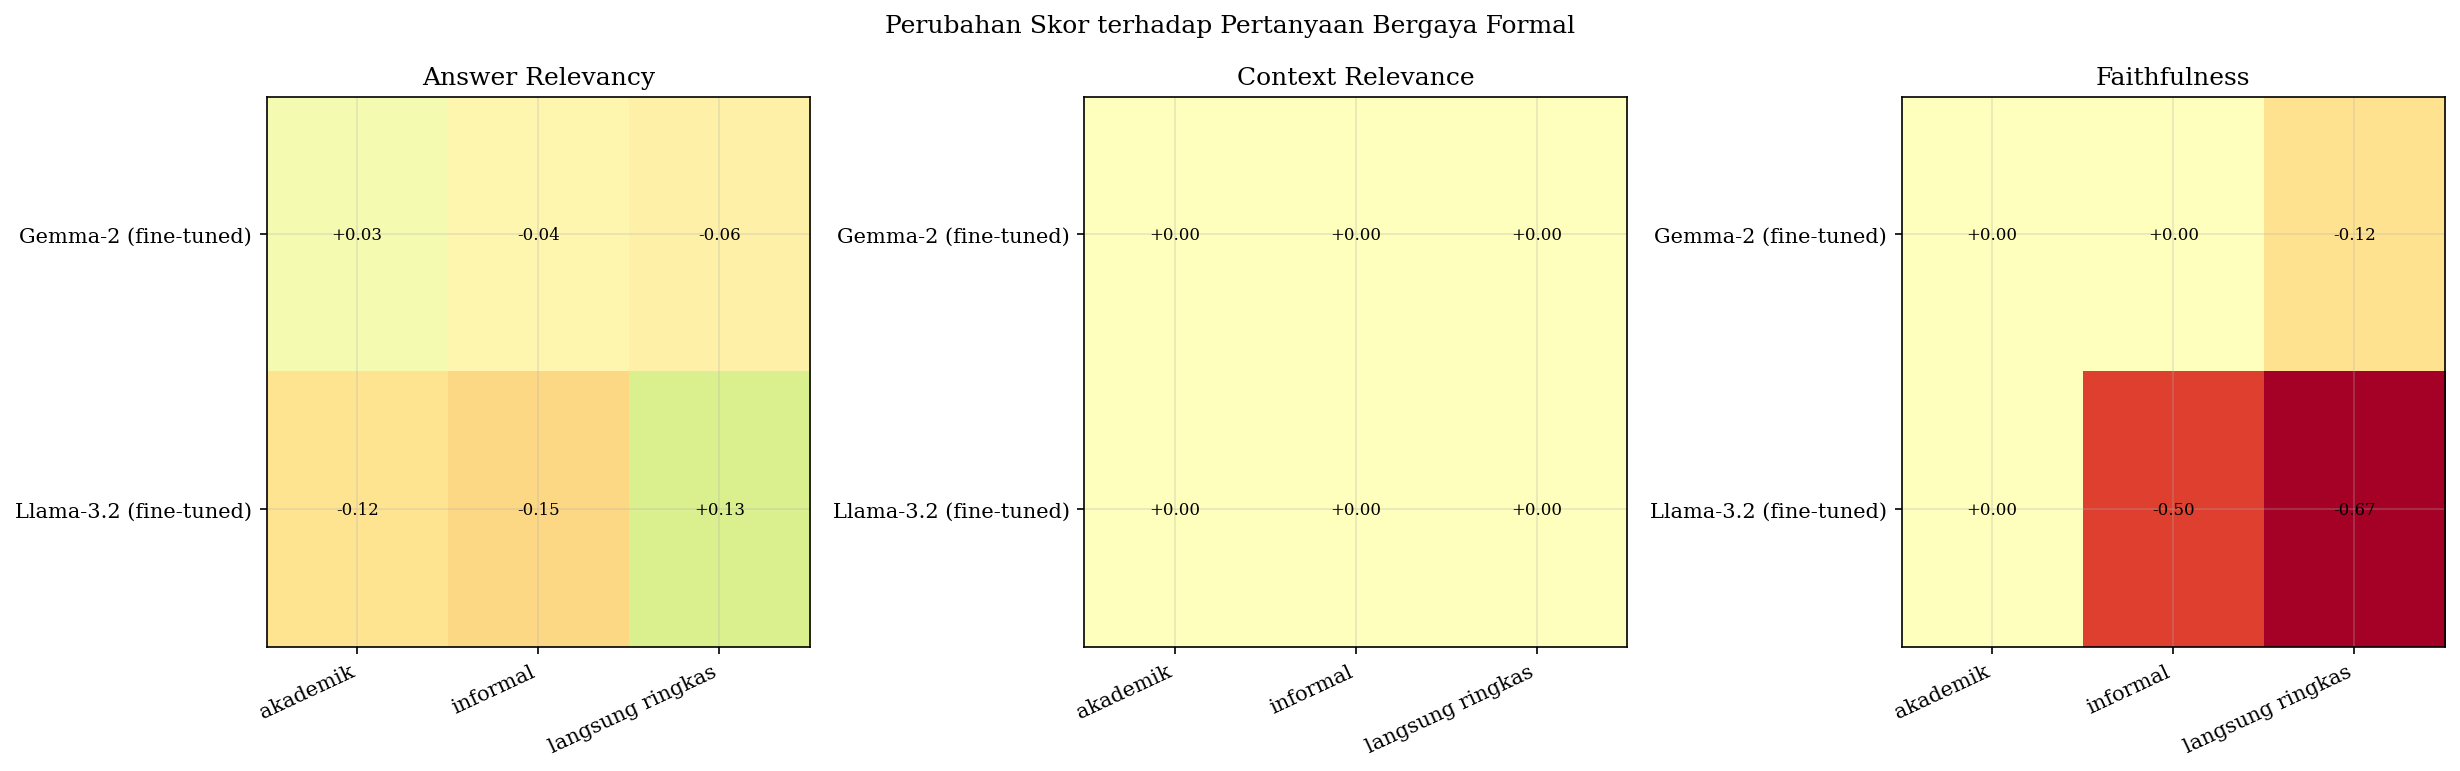

In [17]:
def fig7_robustness_gaya():
    delta_cols = ["delta_faithfulness_vs_formal", "delta_answer_relevancy_vs_formal", "delta_context_relevance_vs_formal"]
    d = style_comparison[style_comparison["variant"] != "formal"].copy()
    panjang = d.melt(id_vars=["model_key", "style"], value_vars=delta_cols,
                     var_name="metric", value_name="delta").dropna(subset=["delta"])
    if panjang.empty:
        lewati("fig07: delta variasi gaya tidak tersedia."); return
    g = panjang.groupby(["model_key", "style", "metric"], as_index=False)["delta"].mean()
    metrics = list(dict.fromkeys(g["metric"]))
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 5.2), squeeze=False)
    for ax, metric in zip(axes[0], metrics):
        sub = g[g["metric"] == metric]
        pivot = sub.pivot(index="model_key", columns="style", values="delta")
        im = ax.imshow(pivot, cmap="RdYlGn", vmin=-max(abs(panjang["delta"]).max(), .01),
                       vmax=max(abs(panjang["delta"]).max(), .01), aspect="auto")
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([str(x).replace("_", " ") for x in pivot.columns], rotation=25, ha="right")
        ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels([label_model(m) for m in pivot.index])
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                v = pivot.iloc[i, j]
                ax.text(j, i, "n/a" if pd.isna(v) else f"{v:+.2f}", ha="center", va="center", fontsize=8)
        ax.set_title(metric.replace("delta_", "").replace("_vs_formal", "").replace("_", " ").title())
    fig.suptitle("Perubahan Skor terhadap Pertanyaan Bergaya Formal")
    plt.tight_layout(); plt.savefig("fig07_robustness_gaya.png", bbox_inches="tight"); plt.show()

fig7_robustness_gaya()


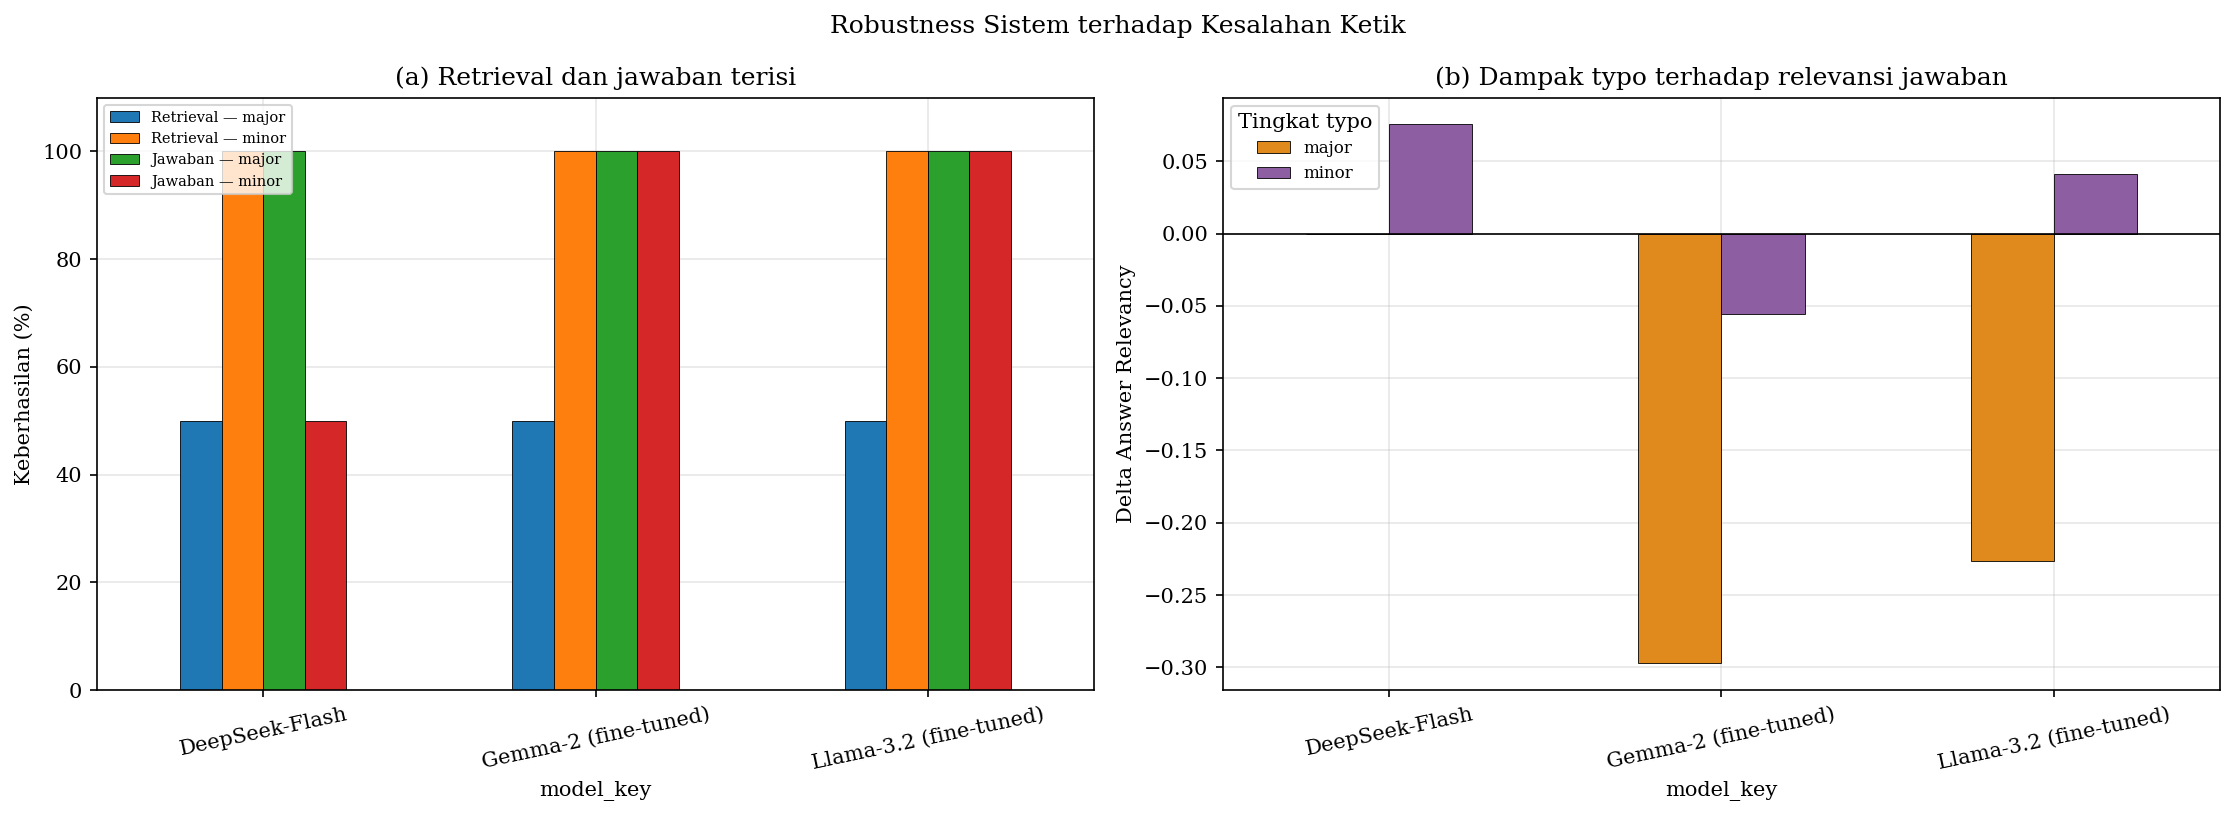

In [18]:
def _terisi(series):
    return series.notna() & ~series.astype(str).str.strip().isin(["", "[]", "{}", "nan", "None"])

def fig8_robustness_typo():
    typo_rows = scenario_results[scenario_results["typo_severity"].notna()].copy()
    if typo_rows.empty:
        lewati("fig08: record typo tidak tersedia."); return
    typo_rows["retrieval_ok"] = _terisi(typo_rows["retrieved_context"])
    typo_rows["answer_ok"] = _terisi(typo_rows["answer"])
    keberhasilan = typo_rows.groupby(["model_key", "typo_severity"])[["retrieval_ok", "answer_ok"]].mean().mul(100)

    delta = (typo_comparison.groupby(["model_key", "typo_severity"])
             [["delta_faithfulness_vs_clean", "delta_answer_relevancy_vs_clean"]].mean())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    ax = axes[0]
    plot = keberhasilan.unstack("typo_severity")
    plot.columns = [f"{'Retrieval' if metrik == 'retrieval_ok' else 'Jawaban'} — {tingkat}"
                    for metrik, tingkat in plot.columns]
    plot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=.4)
    ax.set_xticklabels([label_model(m) for m in plot.index], rotation=12)
    ax.set_ylabel("Keberhasilan (%)"); ax.set_ylim(0, 110)
    ax.set_title("(a) Retrieval dan jawaban terisi"); ax.legend(fontsize=7, title=None)

    ax = axes[1]
    d = delta["delta_answer_relevancy_vs_clean"].unstack("typo_severity")
    d.plot(kind="bar", ax=ax, color=[C_ORANGE, C_PURPLE][:len(d.columns)], edgecolor="black", linewidth=.4)
    ax.axhline(0, color="black", lw=.8); ax.set_xticklabels([label_model(m) for m in d.index], rotation=12)
    ax.set_ylabel("Delta Answer Relevancy"); ax.set_title("(b) Dampak typo terhadap relevansi jawaban")
    ax.legend(fontsize=8, title="Tingkat typo")
    fig.suptitle("Robustness Sistem terhadap Kesalahan Ketik")
    plt.tight_layout(); plt.savefig("fig08_robustness_typo.png", bbox_inches="tight"); plt.show()

fig8_robustness_typo()


## 4. Retrieval dan performa sistem

Seluruh grafik memakai baris pengukuran aktual pada `system_performance_all.csv`.


/tmp/ipykernel_391/2731042686.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[label_model(m) for m in model_order], showmeans=True)


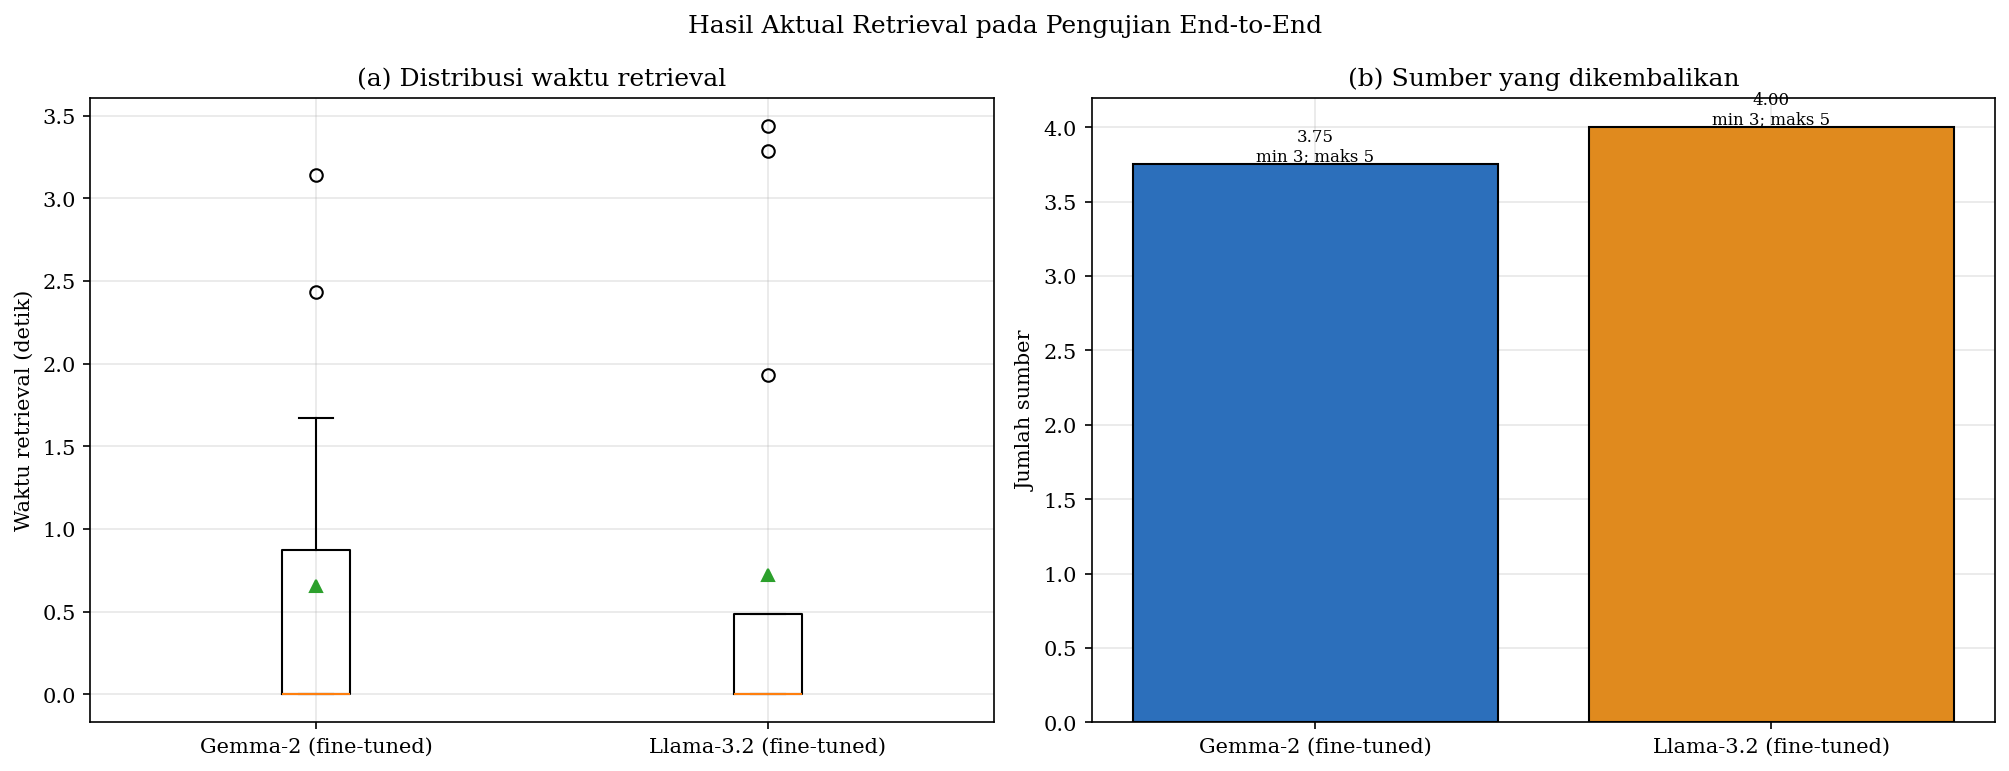

In [19]:
def _e2e():
    d = performance[(performance["test_scope"] == "e2e_system") & (performance["phase"] == "measured")].copy()
    return d[d["status"] == "ok"] if "status" in d else d

def fig9_retrieval():
    d = _e2e()
    if d.empty:
        lewati("fig09: pengukuran end-to-end tidak tersedia."); return
    model_order = sorted(d["model_key"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
    ax = axes[0]
    data = [d.loc[d["model_key"] == m, "retrieval_s"].dropna() for m in model_order]
    ax.boxplot(data, labels=[label_model(m) for m in model_order], showmeans=True)
    ax.set_ylabel("Waktu retrieval (detik)"); ax.set_title("(a) Distribusi waktu retrieval")
    ax = axes[1]
    sumber = d.groupby("model_key")["source_count"].agg(["mean", "min", "max"]).reindex(model_order)
    ax.bar([label_model(m) for m in model_order], sumber["mean"], color=[C_BLUE, C_ORANGE][:len(model_order)], edgecolor="black")
    for x, (m, row) in enumerate(sumber.iterrows()):
        ax.text(x, row["mean"], f"{row['mean']:.2f}\nmin {row['min']:.0f}; maks {row['max']:.0f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Jumlah sumber"); ax.set_title("(b) Sumber yang dikembalikan")
    fig.suptitle("Hasil Aktual Retrieval pada Pengujian End-to-End")
    plt.tight_layout(); plt.savefig("fig09_retrieval.png", bbox_inches="tight"); plt.show()

fig9_retrieval()


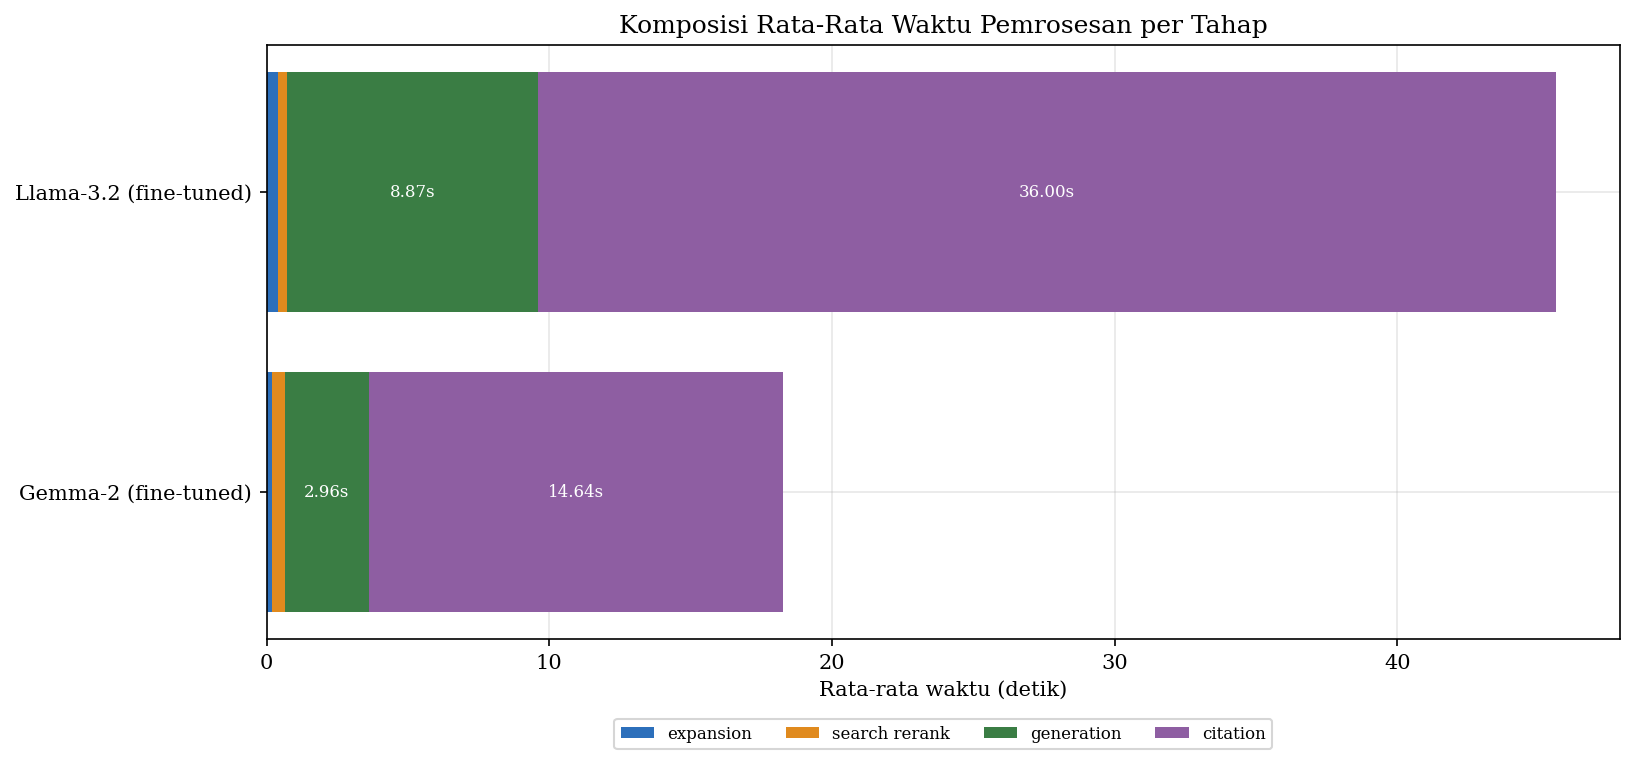

In [20]:
def fig10_komposisi_waktu():
    d = _e2e()
    tahap = [c for c in ["expansion_s", "search_rerank_s", "generation_s", "citation_s"] if c in d and d[c].notna().any()]
    if d.empty or not tahap:
        lewati("fig10: komponen waktu end-to-end tidak tersedia."); return
    rata = d.groupby("model_key")[tahap].mean()
    model_order = list(rata.index)
    fig, ax = plt.subplots(figsize=(11, 5.2))
    left = np.zeros(len(rata))
    colors = [C_BLUE, C_ORANGE, C_GREEN, C_PURPLE]
    for c, warna in zip(tahap, colors):
        nilai = rata[c].to_numpy(float)
        ax.barh(np.arange(len(rata)), nilai, left=left, label=c.replace("_s", "").replace("_", " "), color=warna)
        for yi, (l, v) in enumerate(zip(left, nilai)):
            if v > 0 and v / rata.sum(axis=1).iloc[yi] >= .04:
                    ax.text(l + v / 2, yi, f"{v:.2f}s", ha="center", va="center", fontsize=8,
                              color="white" if v / rata.sum(axis=1).iloc[yi] > .15 else "black")
        left += nilai
    ax.set_yticks(np.arange(len(rata))); ax.set_yticklabels([label_model(m) for m in model_order])
    ax.set_xlabel("Rata-rata waktu (detik)"); ax.set_title("Komposisi Rata-Rata Waktu Pemrosesan per Tahap")
    ax.legend(fontsize=8, ncol=len(tahap), loc="upper center", bbox_to_anchor=(.5, -.12))
    plt.tight_layout(); plt.savefig("fig10_komposisi_waktu.png", bbox_inches="tight"); plt.show()

fig10_komposisi_waktu()


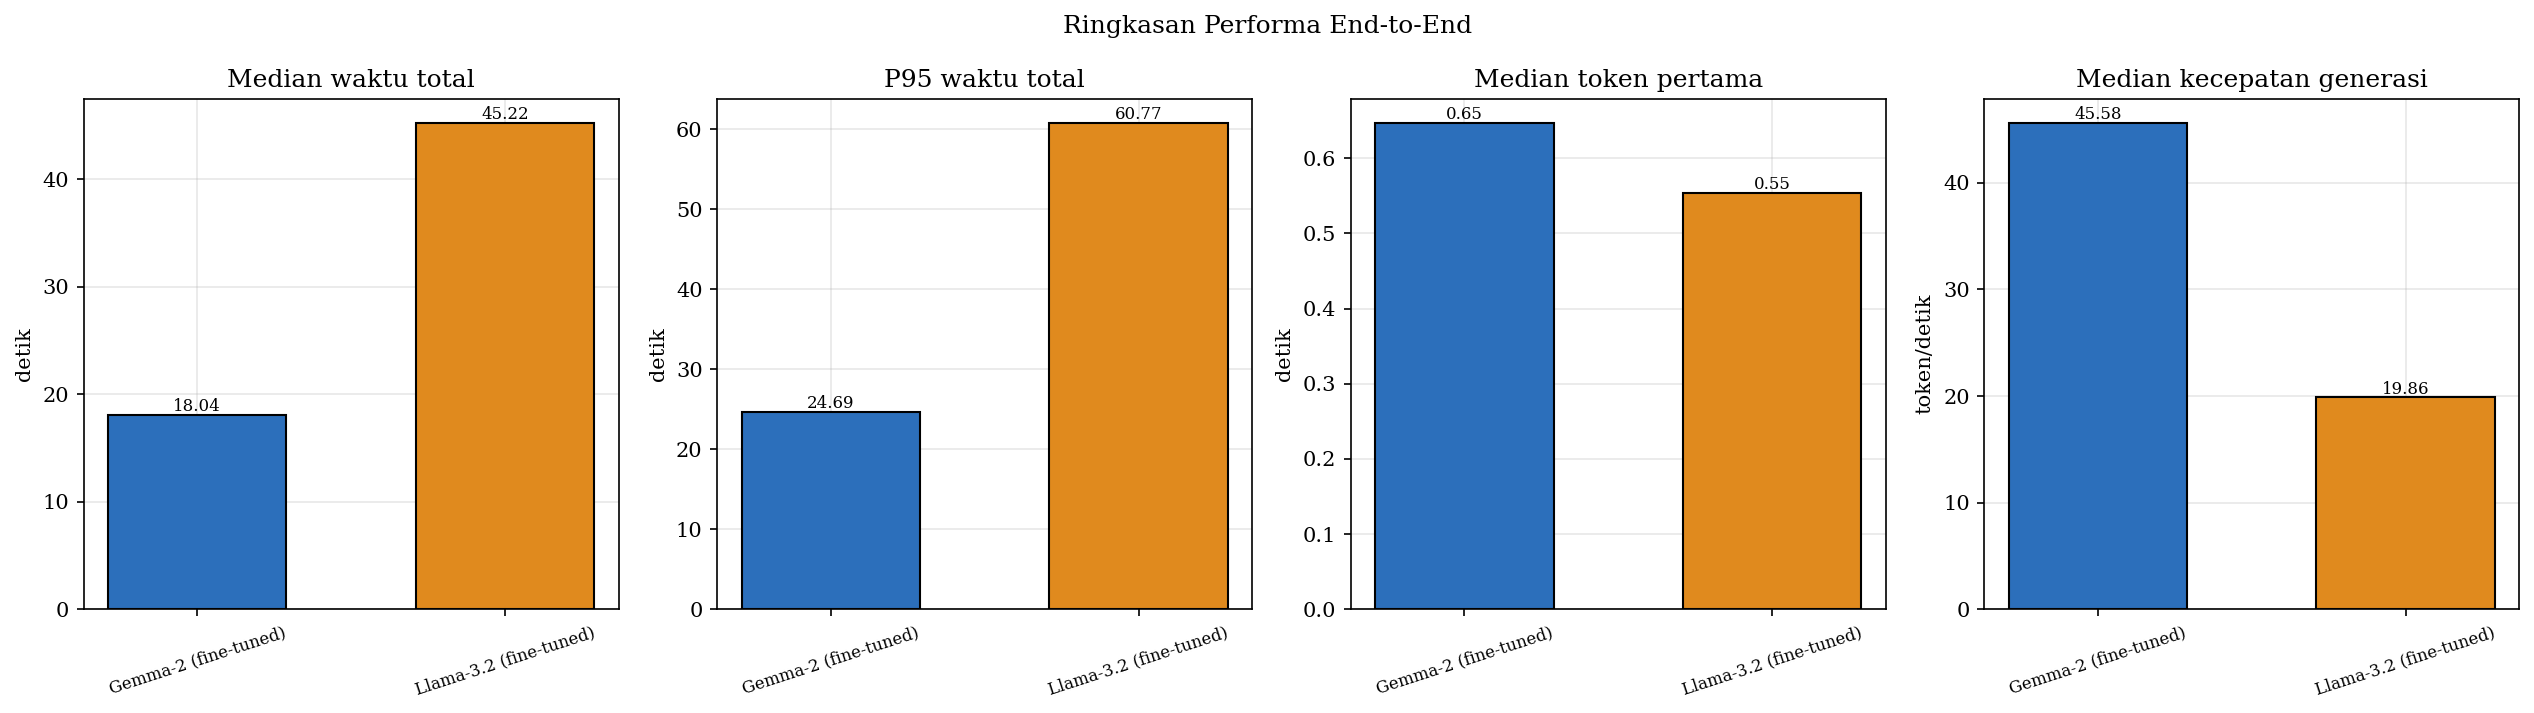

In [21]:
def fig11_ringkasan_performa():
    d = _e2e()
    if d.empty:
        lewati("fig11: pengukuran end-to-end tidak tersedia."); return
    model_order = sorted(d["model_key"].unique())
    rows = []
    for m in model_order:
        s = d[d["model_key"] == m]
        rows.append({
            "model": m,
            "median_total": s["backend_total_s"].median(),
            "p95_total": s["backend_total_s"].quantile(.95),
            "median_first_token": s["first_token_s"].median(),
            "median_token_s": s["answer_tokens_per_s"].median(),
        })
    r = pd.DataFrame(rows).set_index("model")
    panels = [("median_total", "Median waktu total", "detik"),
              ("p95_total", "P95 waktu total", "detik"),
              ("median_first_token", "Median token pertama", "detik"),
              ("median_token_s", "Median kecepatan generasi", "token/detik")]
    fig, axes = plt.subplots(1, len(panels), figsize=(17, 4.8))
    for ax, (kolom, judul, unit) in zip(axes, panels):
        nilai = r[kolom]
        ax.bar([label_model(m) for m in r.index], nilai, color=[C_BLUE, C_ORANGE][:len(r)], edgecolor="black", width=.58)
        for x, v in enumerate(nilai): ax.text(x, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
        ax.set_ylabel(unit); ax.set_title(judul); ax.tick_params(axis="x", labelrotation=18, labelsize=8)
    fig.suptitle("Ringkasan Performa End-to-End")
    plt.tight_layout(); plt.savefig("fig11_ringkasan_performa.png", bbox_inches="tight"); plt.show()

fig11_ringkasan_performa()


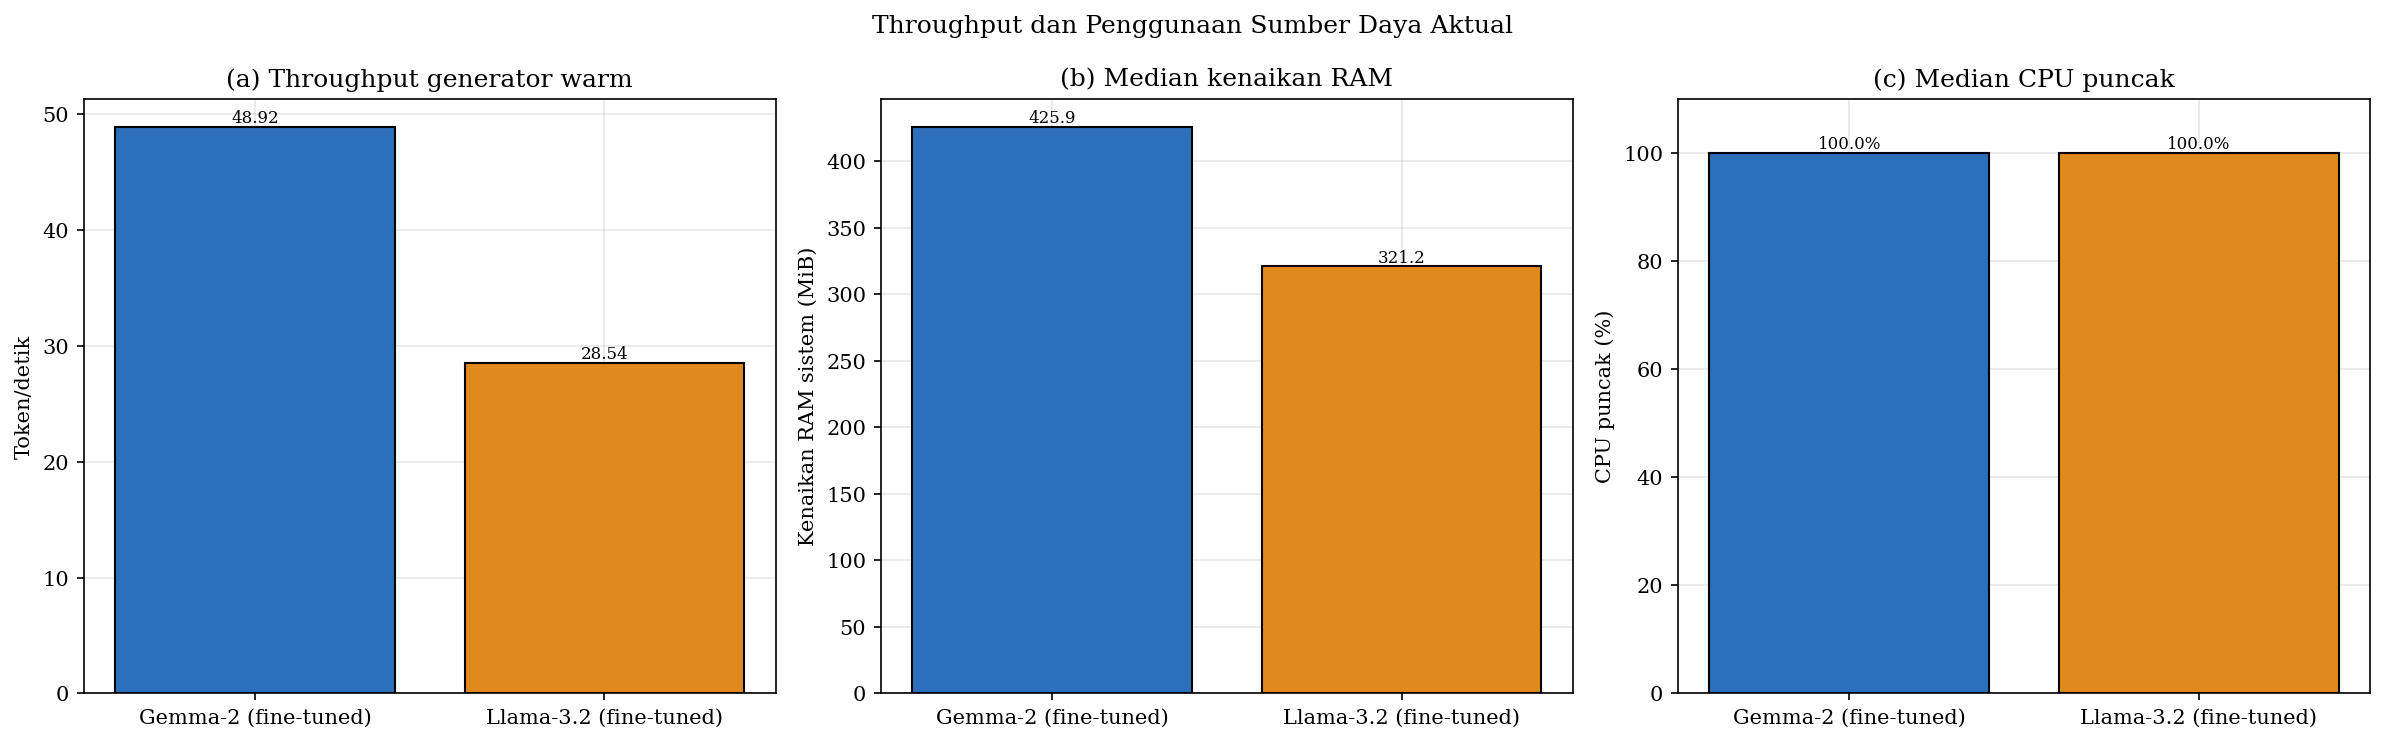

In [22]:
def fig12_throughput_dan_sumberdaya():
    warm = performance[(performance["test_scope"] == "generator_only") & (performance["phase"] == "warm") & (performance["status"] == "ok")]
    e2e = _e2e()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    g = warm.groupby("model_key")["tokens_per_s"].median().dropna()
    ax.bar([label_model(m) for m in g.index], g.values, color=[C_BLUE, C_ORANGE][:len(g)], edgecolor="black")
    for x, v in enumerate(g): ax.text(x, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Token/detik"); ax.set_title("(a) Throughput generator warm")

    ax = axes[1]
    ram = e2e.groupby("model_key")["system_ram_delta_mb"].median().dropna()
    ax.bar([label_model(m) for m in ram.index], ram.values, color=[C_BLUE, C_ORANGE][:len(ram)], edgecolor="black")
    for x, v in enumerate(ram): ax.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Kenaikan RAM sistem (MiB)"); ax.set_title("(b) Median kenaikan RAM")

    ax = axes[2]
    cpu = e2e.groupby("model_key")["peak_cpu_percent"].median().dropna()
    ax.bar([label_model(m) for m in cpu.index], cpu.values, color=[C_BLUE, C_ORANGE][:len(cpu)], edgecolor="black")
    for x, v in enumerate(cpu): ax.text(x, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("CPU puncak (%)"); ax.set_ylim(0, max(105, cpu.max() * 1.1)); ax.set_title("(c) Median CPU puncak")
    fig.suptitle("Throughput dan Penggunaan Sumber Daya Aktual")
    plt.tight_layout(); plt.savefig("fig12_throughput_sumberdaya.png", bbox_inches="tight"); plt.show()

fig12_throughput_dan_sumberdaya()


## 5. Pengujian black-box dan kelengkapan eksekusi


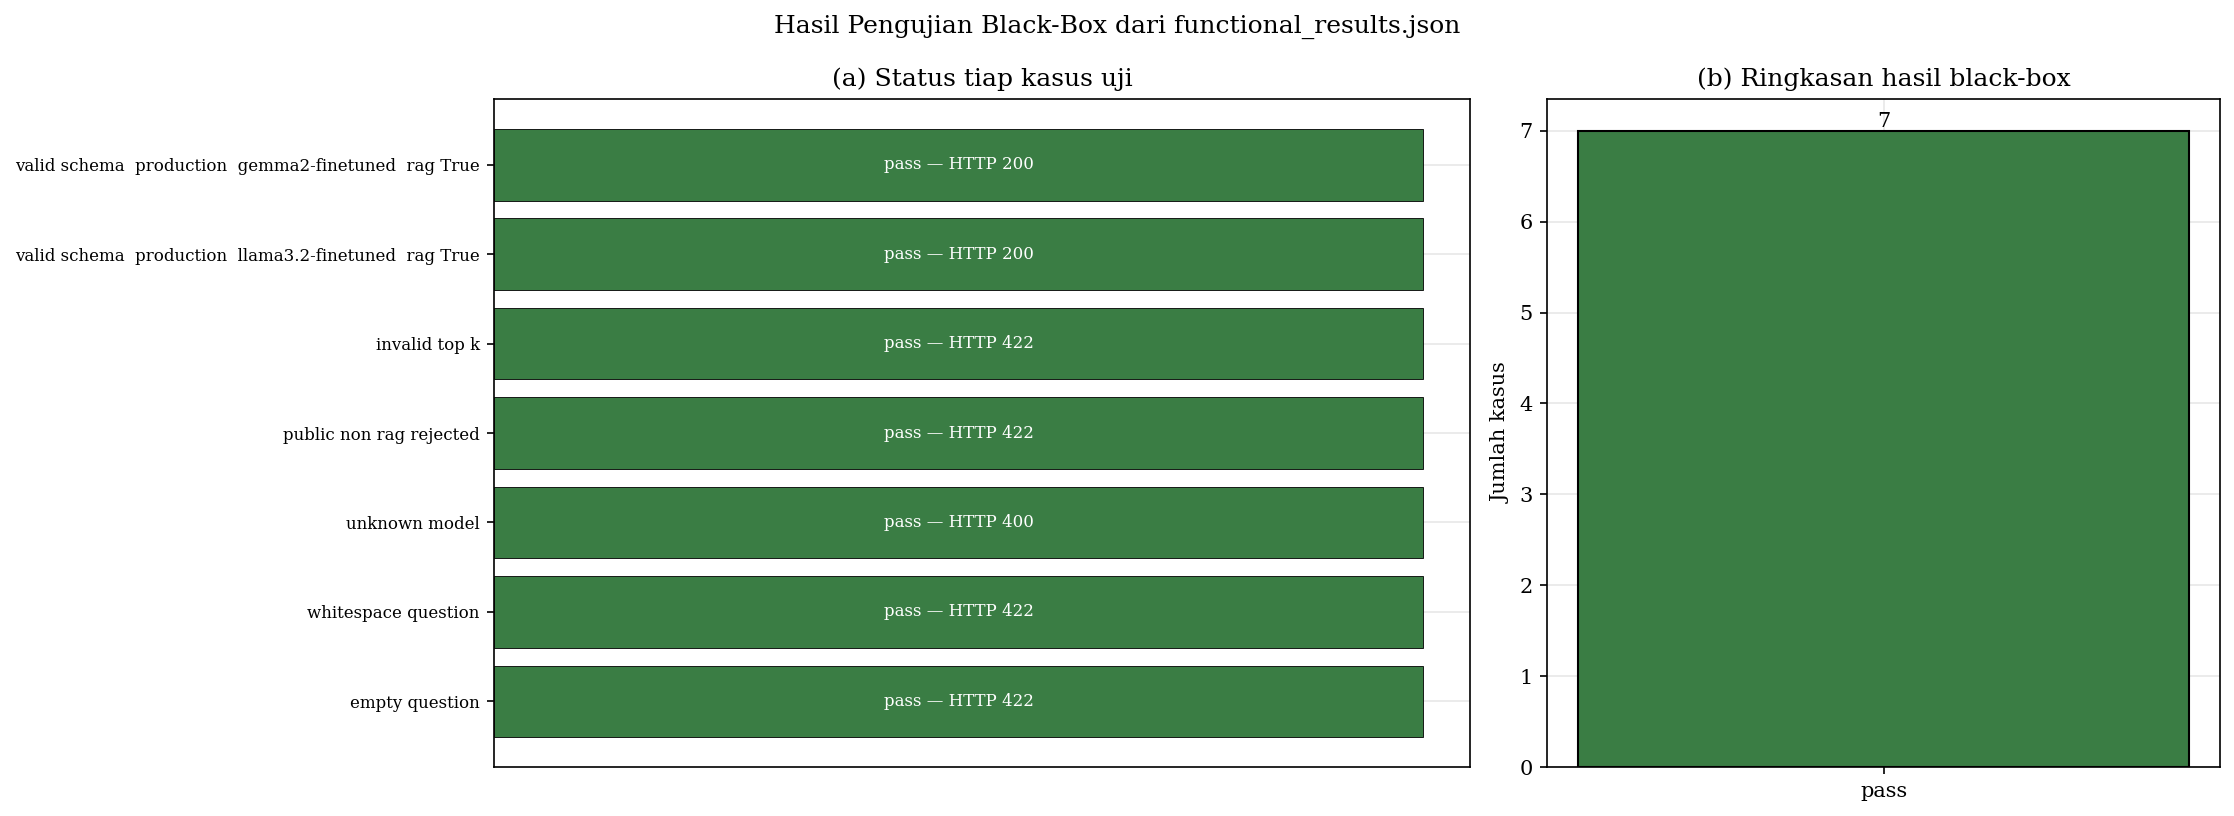

In [23]:
def fig13_blackbox():
    d = pd.DataFrame(functional_results)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.45, 1]})
    ax = axes[0]
    y = np.arange(len(d))
    warna = [C_GREEN if str(s).lower() == "pass" else C_RED for s in d["status"]]
    ax.barh(y, np.ones(len(d)), color=warna, edgecolor="black", linewidth=.4)
    ax.set_yticks(y); ax.set_yticklabels(d["case"].str.replace("_", " "), fontsize=8)
    ax.set_xticks([]); ax.set_xlim(0, 1.05); ax.set_title("(a) Status tiap kasus uji")
    for yi, (status, kode) in enumerate(zip(d["status"], d["status_code"])):
        ax.text(.5, yi, f"{status} — HTTP {kode}", ha="center", va="center", color="white", fontsize=8)

    ax = axes[1]
    ringkas = d["status"].value_counts()
    ax.bar(ringkas.index, ringkas.values,
           color=[C_GREEN if str(x).lower() == "pass" else C_RED for x in ringkas.index], edgecolor="black")
    for x, v in enumerate(ringkas): ax.text(x, v, f"{v:,}", ha="center", va="bottom")
    ax.set_ylabel("Jumlah kasus"); ax.set_title("(b) Ringkasan hasil black-box")
    fig.suptitle("Hasil Pengujian Black-Box dari functional_results.json")
    plt.tight_layout(); plt.savefig("fig13_blackbox.png", bbox_inches="tight"); plt.show()

fig13_blackbox()


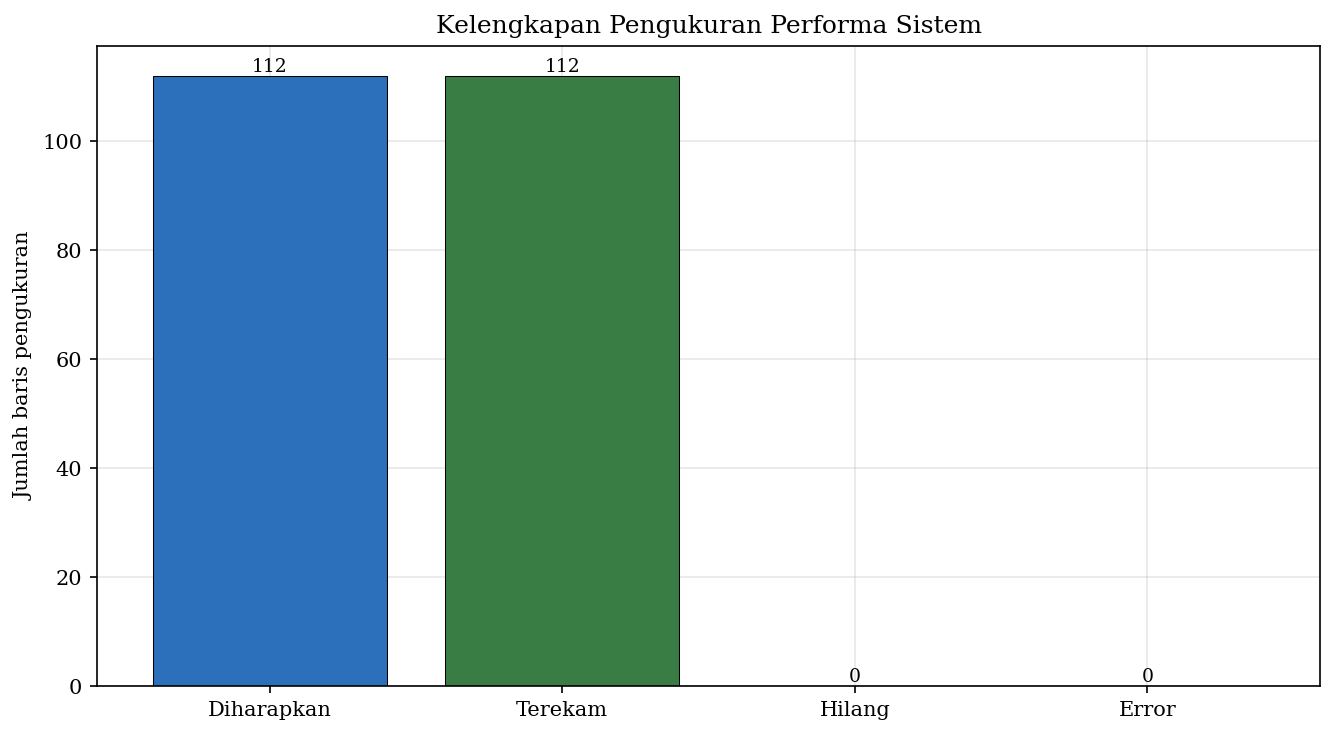

In [24]:
def fig14_coverage_pengujian():
    expected = coverage_system["expected_rows"]
    recorded = coverage_system["recorded_rows"]
    errors = coverage_system["error_rows"]
    missing = len(coverage_system.get("missing_rows", []))
    labels = ["Diharapkan", "Terekam", "Hilang", "Error"]
    nilai = [expected, recorded, missing, errors]
    warna = [C_BLUE, C_GREEN, C_ORANGE, C_RED]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(labels, nilai, color=warna, edgecolor="black", linewidth=.5)
    for x, v in enumerate(nilai): ax.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Jumlah baris pengukuran")
    ax.set_title("Kelengkapan Pengukuran Performa Sistem")
    plt.tight_layout(); plt.savefig("fig14_coverage_pengujian.png", bbox_inches="tight"); plt.show()

fig14_coverage_pengujian()
